# 电影圈数据

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import scipy
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite

In [2]:
import sys
sys.path.append("..")

# 数据处理

## 原始数据

In [3]:
df_raw = pd.read_csv("dwd_cast_works.csv")
df_raw.head()

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,k_genres,is_rating,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray
0,1007816,凌玲,女,10767181,演员,是,5,10767181,妙手千金,电影,...,喜剧/动作,无评分,NaN,暂无评分,NaN,NaN,21534411,2015681,1,NaN
1,1003352,金焰,男,10618303,演员,是,1,10618303,失去的爱情,电影,...,爱情,无评分,NaN,暂无评分,NaN,NaN,21236655,2006753,2,NaN
2,1003352,金焰,男,10601198,演员,是,1,10601198,人道,电影,...,剧情,无评分,NaN,暂无评分,NaN,NaN,21202445,2006753,3,NaN
3,1003352,金焰,男,10566664,演员,是,2,10566664,母亲,电影,...,剧情,无评分,NaN,暂无评分,NaN,NaN,21133377,2006753,4,老邓
4,1013885,阿美莉嘉·奥利沃,女,10727641,演员,是,21,10727641,碟中谍5：神秘国度,电影,...,动作/惊悚/冒险,有评分,7.8,292193,292193.0,1510.0,21455331,2027819,5,Turandot


## 数据筛选
过滤条件
1. 电影
2. 有评分
3. 地区不含其他合拍

In [4]:
# df_movie = df_raw.loc[(df_raw['k_type'] == '电影')
#                       & (df_raw['k_region'].str.contains('中国'))].copy()
df_movie = df_raw.loc[(df_raw['k_region'] != '其他合拍')].copy()
# k_cast_id转为str
df_movie['k_cast_id'] = df_movie['k_cast_id'].apply(lambda x: str(x))
# 仅保留演员，导演数
df_movie = df_movie[df_movie['k_role'].isin(['演员', '导演'])]
df_movie = df_movie.reset_index(drop=True).copy(deep=True)
# 添加新的movie_id_m列
df_movie['movie_id_m'] = df_movie['k_movie_id'].apply(lambda x: 'm' + str(x))
df_movie

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,is_rating,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m
0,1007816,凌玲,女,10767181,演员,是,5,10767181,妙手千金,电影,...,无评分,NaN,暂无评分,NaN,NaN,21534411,2015681,1,NaN,m21534411
1,1003352,金焰,男,10618303,演员,是,1,10618303,失去的爱情,电影,...,无评分,NaN,暂无评分,NaN,NaN,21236655,2006753,2,NaN,m21236655
2,1003352,金焰,男,10601198,演员,是,1,10601198,人道,电影,...,无评分,NaN,暂无评分,NaN,NaN,21202445,2006753,3,NaN,m21202445
3,1003352,金焰,男,10566664,演员,是,2,10566664,母亲,电影,...,无评分,NaN,暂无评分,NaN,NaN,21133377,2006753,4,老邓,m21133377
4,1003424,蒋君超,男,10777680,演员,是,2,10777680,影坛风月,电影,...,无评分,NaN,暂无评分,NaN,NaN,21555409,2006897,6,NaN,m21555409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449847,34951835,李卿,男,36744438,演员,是,17,36744438,书卷一梦,电视剧,...,无评分,NaN,暂无评分,NaN,NaN,73488925,69903719,608925,断山虎,m73488925
449848,35415094,张可,女,7053738,演员,否,999,7053738,樱桃,电视剧,...,有评分,5.7,2003,2003.0,107.0,14107525,70830237,608926,NaN,m14107525
449849,1314059,徐小凤,女,26901136,演员,否,999,26901136,天龙酒店,电影,...,无评分,NaN,暂无评分,NaN,NaN,53802321,2628167,608927,NaN,m53802321
449850,1385616,马英智,男,34925531,演员,是,3,34925531,小戏骨：红色娘子军,电视剧,...,无评分,NaN,暂无评分,NaN,NaN,69851111,2771281,608928,南霸天,m69851111


In [5]:
df_movie[df_movie['k_title'] == '让子弹飞']

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,is_rating,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m
23414,30276936,陈磊,男,3742360,演员,否,999,3742360,让子弹飞,电影,...,有评分,9.0,1571537,1571537.0,3761.0,7484769,60553921,31127,受辱民女夫,m7484769
52055,27504347,杨奇雨,男,3742360,演员,是,21,3742360,让子弹飞,电影,...,有评分,9.0,1571537,1571537.0,3761.0,7484769,55008743,69885,胡百,m7484769
86015,27250655,周润发,男,3742360,演员,是,3,3742360,让子弹飞,电影,...,有评分,9.0,1571537,1571537.0,3761.0,7484769,54501359,116057,黄四郎 / 杨万楼,m7484769
96834,27238280,胡军,男,3742360,演员,是,14,3742360,让子弹飞,电影,...,有评分,9.0,1571537,1571537.0,3761.0,7484769,54476609,130722,假张麻子,m7484769
117142,27481219,冯小刚,男,3742360,演员,是,13,3742360,让子弹飞,电影,...,有评分,9.0,1571537,1571537.0,3761.0,7484769,54962487,158187,汤师爷,m7484769
119469,30276937,沙瑀,男,3742360,演员,否,999,3742360,让子弹飞,电影,...,有评分,9.0,1571537,1571537.0,3761.0,7484769,60553923,161435,鹅人,m7484769
157188,27232187,张默,男,3742360,演员,是,6,3742360,让子弹飞,电影,...,有评分,9.0,1571537,1571537.0,3761.0,7484769,54464423,212629,老六,m7484769
163265,27243602,周韵,女,3742360,演员,是,8,3742360,让子弹飞,电影,...,有评分,9.0,1571537,1571537.0,3761.0,7484769,54487253,220833,花姐,m7484769
197986,27206595,葛优,男,3742360,演员,是,2,3742360,让子弹飞,电影,...,有评分,9.0,1571537,1571537.0,3761.0,7484769,54413239,267929,马邦德,m7484769
201696,27504343,马珂,男,3742360,演员,是,15,3742360,让子弹飞,电影,...,有评分,9.0,1571537,1571537.0,3761.0,7484769,55008735,272919,八岁,m7484769


## 影人职责合并

In [6]:
# 合并影人职责
df_cast = df_movie[['k_cast_id', 'cast_name', 'k_role']].drop_duplicates()
df_cast_agg = df_cast.groupby(['k_cast_id', 'cast_name'])['k_role'].apply(lambda x: '/'.join(sorted(x.unique()))).reset_index()
df_cast_agg

,k_cast_id,cast_name,k_role
0,2000437,李香凝,演员
1,2000457,吉娜·卡拉诺,演员
2,2000515,理查德·格里克,演员
3,2000941,司汗,演员
4,2001011,凯文·格劳特,导演
...,...,...,...
53654,75884265,曹忆,演员
53655,76124365,黄浩忠,导演
53656,76135081,何田田,演员
53657,76349227,方誉媛,演员


In [7]:
df_movie['cast_role_agg'] = df_movie['k_cast_id'].map(
    df_cast_agg.set_index('k_cast_id')['k_role']
)
df_movie

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m,cast_role_agg
0,1007816,凌玲,女,10767181,演员,是,5,10767181,妙手千金,电影,...,NaN,暂无评分,NaN,NaN,21534411,2015681,1,NaN,m21534411,演员
1,1003352,金焰,男,10618303,演员,是,1,10618303,失去的爱情,电影,...,NaN,暂无评分,NaN,NaN,21236655,2006753,2,NaN,m21236655,演员
2,1003352,金焰,男,10601198,演员,是,1,10601198,人道,电影,...,NaN,暂无评分,NaN,NaN,21202445,2006753,3,NaN,m21202445,演员
3,1003352,金焰,男,10566664,演员,是,2,10566664,母亲,电影,...,NaN,暂无评分,NaN,NaN,21133377,2006753,4,老邓,m21133377,演员
4,1003424,蒋君超,男,10777680,演员,是,2,10777680,影坛风月,电影,...,NaN,暂无评分,NaN,NaN,21555409,2006897,6,NaN,m21555409,导演/演员
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449847,34951835,李卿,男,36744438,演员,是,17,36744438,书卷一梦,电视剧,...,NaN,暂无评分,NaN,NaN,73488925,69903719,608925,断山虎,m73488925,演员
449848,35415094,张可,女,7053738,演员,否,999,7053738,樱桃,电视剧,...,5.7,2003,2003.0,107.0,14107525,70830237,608926,NaN,m14107525,演员
449849,1314059,徐小凤,女,26901136,演员,否,999,26901136,天龙酒店,电影,...,NaN,暂无评分,NaN,NaN,53802321,2628167,608927,NaN,m53802321,演员
449850,1385616,马英智,男,34925531,演员,是,3,34925531,小戏骨：红色娘子军,电视剧,...,NaN,暂无评分,NaN,NaN,69851111,2771281,608928,南霸天,m69851111,演员


In [8]:
df_movie[df_movie['cast_name'] == '张艺谋']

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m,cast_role_agg
659,27260166,张艺谋,男,1292365,导演,是,1,1292365,活着,电影,...,9.3,678477,678477.0,2512.0,2584779,54520381,762,NaN,m2584779,导演/演员
3513,27260166,张艺谋,男,1294963,导演,是,1,1294963,一个都不能少,电影,...,7.7,120767,120767.0,964.0,2589975,54520381,4254,NaN,m2589975,导演/演员
7030,27260166,张艺谋,男,35294995,演员,是,40,35294995,我和我的父辈,电影,...,6.9,175739,175739.0,1101.0,70590039,54520381,9034,电视台台长,m70590039,导演/演员
14104,27260166,张艺谋,男,1294007,导演,是,1,1294007,我的父亲母亲,电影,...,8.2,116620,116620.0,978.0,2588063,54520381,18504,NaN,m2588063,导演/演员
24633,27260166,张艺谋,男,1308070,演员,是,1,1308070,老井,电影,...,8.0,16354,16354.0,362.0,2616189,54520381,32780,孙旺泉,m2616189,导演/演员
35028,27260166,张艺谋,男,26694491,导演,是,1,26694491,大红灯笼高高挂,电影,...,8.8,3372,3372.0,172.0,53389031,54520381,46812,NaN,m53389031,导演/演员
38439,27260166,张艺谋,男,1297879,演员,否,999,1297879,大阅兵,电影,...,6.8,1946,1946.0,115.0,2595807,54520381,51452,军官,m2595807,导演/演员
97595,27260166,张艺谋,男,35215390,导演,是,1,35215390,狙击手,电影,...,7.7,340264,340264.0,1619.0,70430829,54520381,131717,NaN,m70430829,导演/演员
97603,27260166,张艺谋,男,33447633,导演,是,1,33447633,坚如磐石,电影,...,6.0,344998,344998.0,1439.0,66895315,54520381,131729,NaN,m66895315,导演/演员
114941,27260166,张艺谋,男,32493124,导演,是,1,32493124,悬崖之上,电影,...,7.6,597494,597494.0,2131.0,64986297,54520381,155123,NaN,m64986297,导演/演员


## 有评分数据

In [9]:
df_movie_rated = df_movie[df_movie['is_rating'] == '有评分'].copy()
df_movie_rated = df_movie_rated.reset_index(drop=True).copy(deep=True)
df_movie_rated

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m,cast_role_agg
0,1017182,陈燕燕,女,10771202,演员,是,1,10771202,深闺疑云,电影,...,7.8,92,92.0,27.0,21542453,2034413,54,赵兰,m21542453,演员
1,1043845,刘志荣,男,10581318,演员,是,11,10581318,四大家族之龙虎兄弟,电影,...,7.8,2290,2290.0,134.0,21162685,2087739,75,NaN,m21162685,导演/演员
2,1050373,茅瑛,女,10573512,演员,是,1,10573512,鬼娘子,电影,...,5.8,235,235.0,37.0,21147073,2100795,79,NaN,m21147073,演员
3,1124360,利智,女,10581318,演员,是,3,10581318,四大家族之龙虎兄弟,电影,...,7.8,2290,2290.0,134.0,21162685,2248769,94,NaN,m21162685,演员
4,1314471,王挺,男,10531190,演员,是,1,10531190,惊天动地,电视剧,...,8.5,326,326.0,53.0,21062429,2628991,147,NaN,m21062429,导演/演员
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258252,1354509,林泳淘,女,26984991,演员,否,999,26984991,婚姻合伙人,电视剧,...,5.8,1259,1259.0,85.0,53970031,2709067,608916,邓秀玉,m53970031,演员
258253,27496534,刘芊蒂,女,2337597,演员,是,2,2337597,操行零分,电影,...,7.0,211,211.0,38.0,4675243,54993117,608920,NaN,m4675243,演员
258254,27565771,董亚春,女,2270516,导演,是,2,2270516,八月一日,电影,...,6.4,1123,1123.0,85.0,4541081,55131591,608921,NaN,m4541081,导演
258255,35415094,张可,女,7053738,演员,否,999,7053738,樱桃,电视剧,...,5.7,2003,2003.0,107.0,14107525,70830237,608926,NaN,m14107525,演员


## 保存为csv

In [10]:
df_movie.to_csv("movie_data.csv", index=False)
df_movie_rated.to_csv("movie_data_rated.csv", index=False)

# 数据统计

## 年度数据

In [11]:
# 按年统计每年的电影数量
df_count_by_year = df_movie_rated.groupby('k_movie_year')['movie_id_m'].nunique().reset_index()
df_count_by_year.columns = ['year', 'movie_count']
df_count_by_year = df_count_by_year.sort_values('year')
df_count_by_year

,year,movie_count
0,1905,1
1,1913,2
2,1921,1
3,1923,1
4,1925,2
...,...,...
101,2022,500
102,2023,517
103,2024,438
104,2025,239


/opt/anaconda3/envs/net_charts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/net_charts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/net_charts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/net_charts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/net_charts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: User

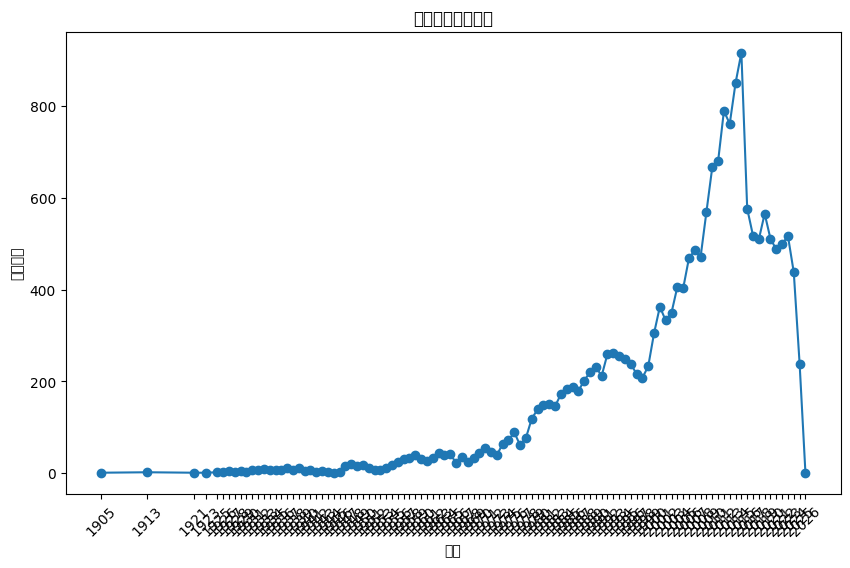

In [12]:
# 绘图
plt.figure(figsize=(10, 6))
plt.plot(df_count_by_year['year'], df_count_by_year['movie_count'], marker='o')
plt.title('年度电影数量统计')
plt.xlabel('年份')
plt.ylabel('电影数量')
plt.xticks(df_count_by_year['year'], rotation=45)
# plt.tight_layout()
plt.show()